In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis : Preprocessed_csv.csv

## Data Overview

In [2]:
# Load the preprocessed dataset
file_path = 'datasets/Preprocessed_csv.csv'
preprocessed_data = pd.read_csv(file_path)

# Display the first few rows of the dataset and its shape
preprocessed_data_head = preprocessed_data.head()
dataset_shape = preprocessed_data.shape

preprocessed_data_head, dataset_shape

(         Date                                         clean_text  \
 0  2021-02-01  sent givedirectly great work distributing fund...   
 1  2021-02-02  watch video learn truth doublespend separate f...   
 2  2021-02-03  min video review strategy simple advanced help...   
 3  2021-02-04               fair elon gave chance load bag early   
 4  2021-02-05  minute video ive learned much cant smash like ...   
 
    favorite_count                                          full_text  \
 0          3496.0  i sent some! https://t.co/mfyrz35zjf\r\n\r\nyo...   
 1           109.0  watch this video to learn the truth about what...   
 2           153.0  in this 7min video, i review strategies from s...   
 3           196.0  to be fair elon gave all of you the chance to ...   
 4           100.0  â30 minutes into the video and i've learned ...   
 
    reply_count  retweet_count  \
 0        731.0            686   
 1          5.0             25   
 2          9.0             24   
 3      

The dataset consists of 842 rows and 26 columns.
The first few rows of the dataset reveal a mix of textual and numerical data.

### Columns in the Dataset:
The columns include 'Date', 'clean_text', 'favorite_count', 'full_text', 'reply_count', 'retweet_count', 'entity_vectors', 'clean_text_vector', 'importance_coefficient', 'importance_coefficient_normalized', and several others related to Bitcoin's market data like 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'daily_return', 'historical_volatility', 'first_derivative', 'second_derivative', and 'target'.

### Data Types:
The dataset contains both time-series data (e.g., 'Date') and textual data (e.g., 'clean_text', 'full_text').
It also includes various numerical metrics, such as sentiment analysis results, tweet engagement measures, and Bitcoin market data.

## Data Inspection

In [3]:
# Inspecting the data types and missing values in the dataset
data_types = preprocessed_data.dtypes
missing_values = preprocessed_data.isnull().sum()

data_types, missing_values

(Date                                  object
 clean_text                            object
 favorite_count                       float64
 full_text                             object
 reply_count                          float64
 retweet_count                          int64
 entity_vectors                        object
 clean_text_vector                     object
 importance_coefficient               float64
 importance_coefficient_normalized    float64
 compound                             float64
 sentiment_type                         int64
 negative_sentiment_score             float64
 positive_sentiment_score             float64
 neutral_sentiment_score              float64
 Open                                 float64
 High                                 float64
 Low                                  float64
 Close                                float64
 Adj Close                            float64
 Volume                                 int64
 daily_return                     

The data inspection reveals the following:

* **Data Types:** The dataset consists of a variety of data types, including:
  * *object* (e.g., 'Date', 'clean_text', 'full_text', 'entity_vectors', 'clean_text_vector').
  * *float64* for many numeric columns like 'favorite_count', 'reply_count', 'importance_coefficient', and Bitcoin market data such as 'Open', 'High', 'Low', 'Close', 'daily_return', etc.
  * *int64* for some columns like 'retweet_count', 'sentiment_type', 'Volume', and 'target'.


* **Missing Values:** There are no missing values in any of the columns in this dataset. This suggests that the dataset has either been preprocessed to handle missing values or originally did not have any missing data.

## Statistical Summary

In [4]:
# Generating a statistical summary for the numerical columns
numerical_summary = preprocessed_data.describe()

numerical_summary

,favorite_count,reply_count,retweet_count,importance_coefficient,importance_coefficient_normalized,compound,sentiment_type,negative_sentiment_score,positive_sentiment_score,neutral_sentiment_score,...,High,Low,Close,Adj Close,Volume,daily_return,historical_volatility,first_derivative,second_derivative,target
count,842.000000,842.000000,842.000000,842.000000,842.000000,842.000000,842.000000,842.000000,842.000000,842.000000,...,842.000000,842.000000,842.000000,842.000000,8.420000e+02,842.000000,842.000000,842.000000,842.000000,842.000000
mean,4669.837292,614.371734,791.115202,10437.975653,0.018044,0.152647,0.295724,0.041099,0.099404,0.859490,...,36164.934086,34400.061520,35325.545974,35325.545974,3.401711e+10,0.000428,0.043005,-9.077922,-2.393705,0.485748
std,13366.676866,1542.906749,2756.409716,28539.054756,0.049336,0.403813,0.781295,0.074413,0.107828,0.125347,...,14177.509832,13331.663594,13788.682519,13788.682519,1.999092e+10,0.035600,0.006905,1394.339064,2004.034842,0.500094
min,0.000000,0.000000,0.000000,5.500000,0.000010,-0.931300,-1.000000,0.000000,0.000000,0.125000,...,16253.050000,15599.050000,15787.280000,15787.280000,7.044911e+09,-0.160000,0.000000,-7554.040000,-8398.820000,0.000000
25%,352.500000,43.000000,44.000000,832.125000,0.001439,0.000000,0.000000,0.000000,0.000000,0.781000,...,23128.370000,22236.640000,22646.490000,22646.490000,2.272177e+10,-0.020000,0.040000,-529.625000,-928.727500,0.000000
50%,2319.500000,225.500000,228.500000,5068.750000,0.008762,0.000000,0.000000,0.000000,0.083000,0.868000,...,34647.170000,32351.555000,33652.290000,33652.290000,3.060373e+10,-0.000000,0.040000,-12.710000,1.600000,0.000000
75%,5001.500000,625.750000,724.750000,11259.000000,0.019464,0.450000,1.000000,0.065000,0.163000,1.000000,...,47390.567500,45153.992500,46431.387500,46431.387500,3.947940e+10,0.020000,0.050000,561.732500,890.405000,1.000000
max,286955.000000,21865.000000,53147.000000,578465.000000,1.000000,0.982900,1.000000,0.537000,0.583000,1.000000,...,68789.620000,66382.060000,67566.830000,67566.830000,3.509679e+11,0.190000,0.070000,7293.020000,9687.260000,1.000000


* **Numerical Columns:**
  * *Count:* Indicates the number of non-missing values in each column.
  * *Mean:* The average value in each column.
  * *Std (Standard Deviation):* Measures the amount of variation or dispersion in the data.
  * *Min:* The minimum value in each column.
  * *25% (First Quartile):* The value below which 25% of the data falls.
  * *50% (Median):* The middle value of the dataset.
  * *75% (Third Quartile):* The value below which 75% of the data falls.
  * *Max:* The maximum value in each column.

In [5]:
# Generating a summary for categorical columns (for 'object' type columns)
categorical_columns = preprocessed_data.select_dtypes(include=['object']).columns
categorical_summary = preprocessed_data[categorical_columns].describe()

categorical_summary

,Date,clean_text,full_text,entity_vectors,clean_text_vector
count,842,842,842,842,842
unique,842,822,841,111,817
top,2021-02-01,bitcoin,#bitcoin,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
freq,1,7,2,620,11


* **Categorical Columns:**
  * *Count:* The number of non-missing values.
  * *Unique:* The number of unique categories in each column.
  * *Top:* The most common category.
  * *Freq:* The frequency of the most common category.

## Data Distribution Analysis

c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na opti

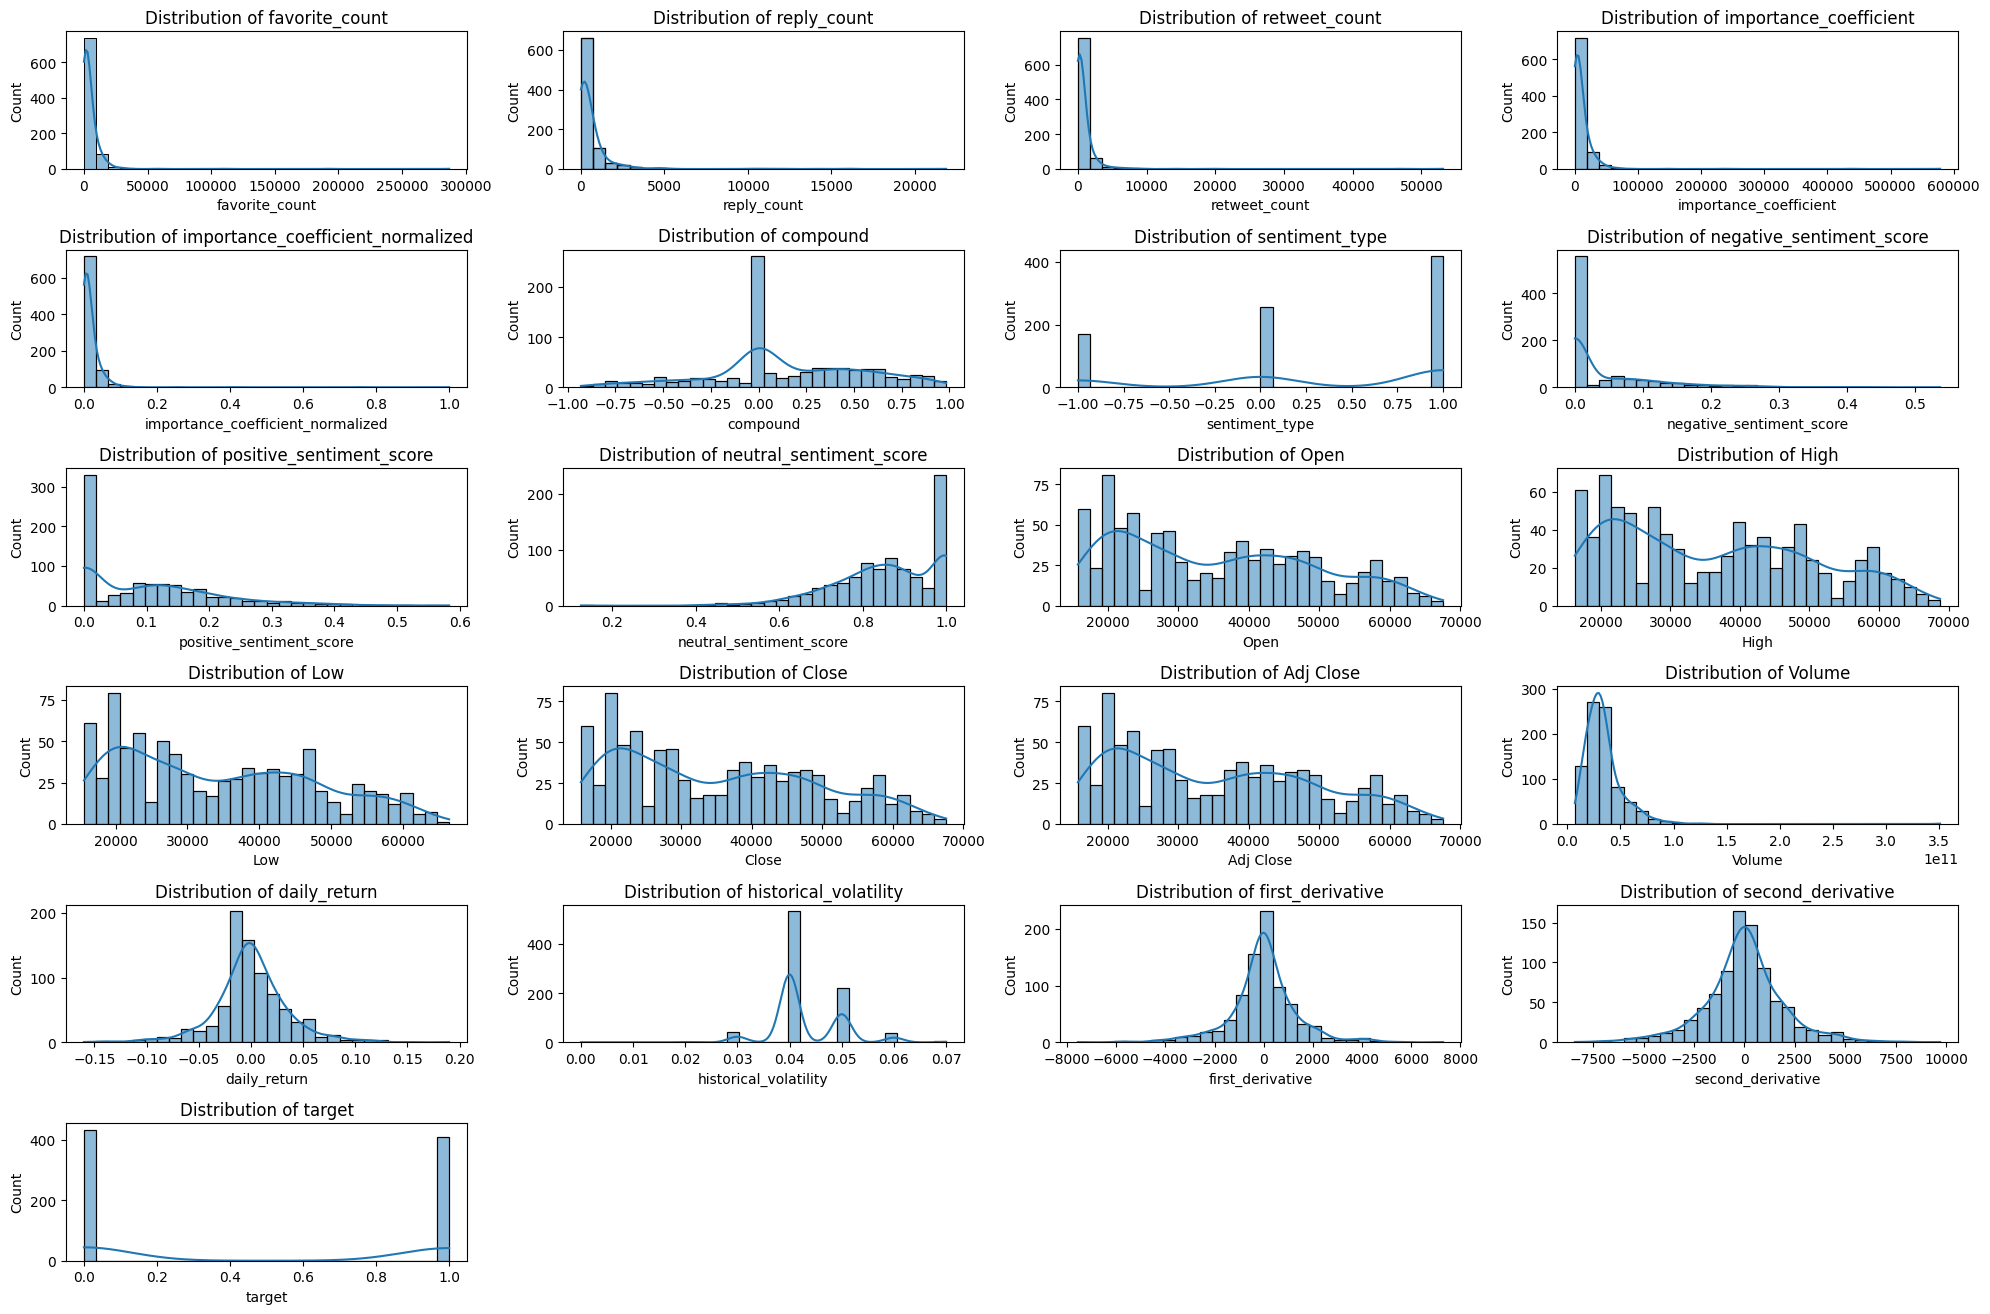

In [6]:
# Selecting numerical columns for distribution analysis
numerical_columns = preprocessed_data.select_dtypes(include=['float64', 'int64']).columns

# Plotting the distribution of each numerical column
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_columns):
    plt.subplot(7, 4, i+1)
    sns.histplot(preprocessed_data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

* Most variables show varied distributions, with some exhibiting clear peaks (modes), while others are more uniformly distributed.

* Certain columns might have a large number of zeros or a single dominant value, as suggested by spikes in the histograms.

## Outlier Detection:

c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is depr

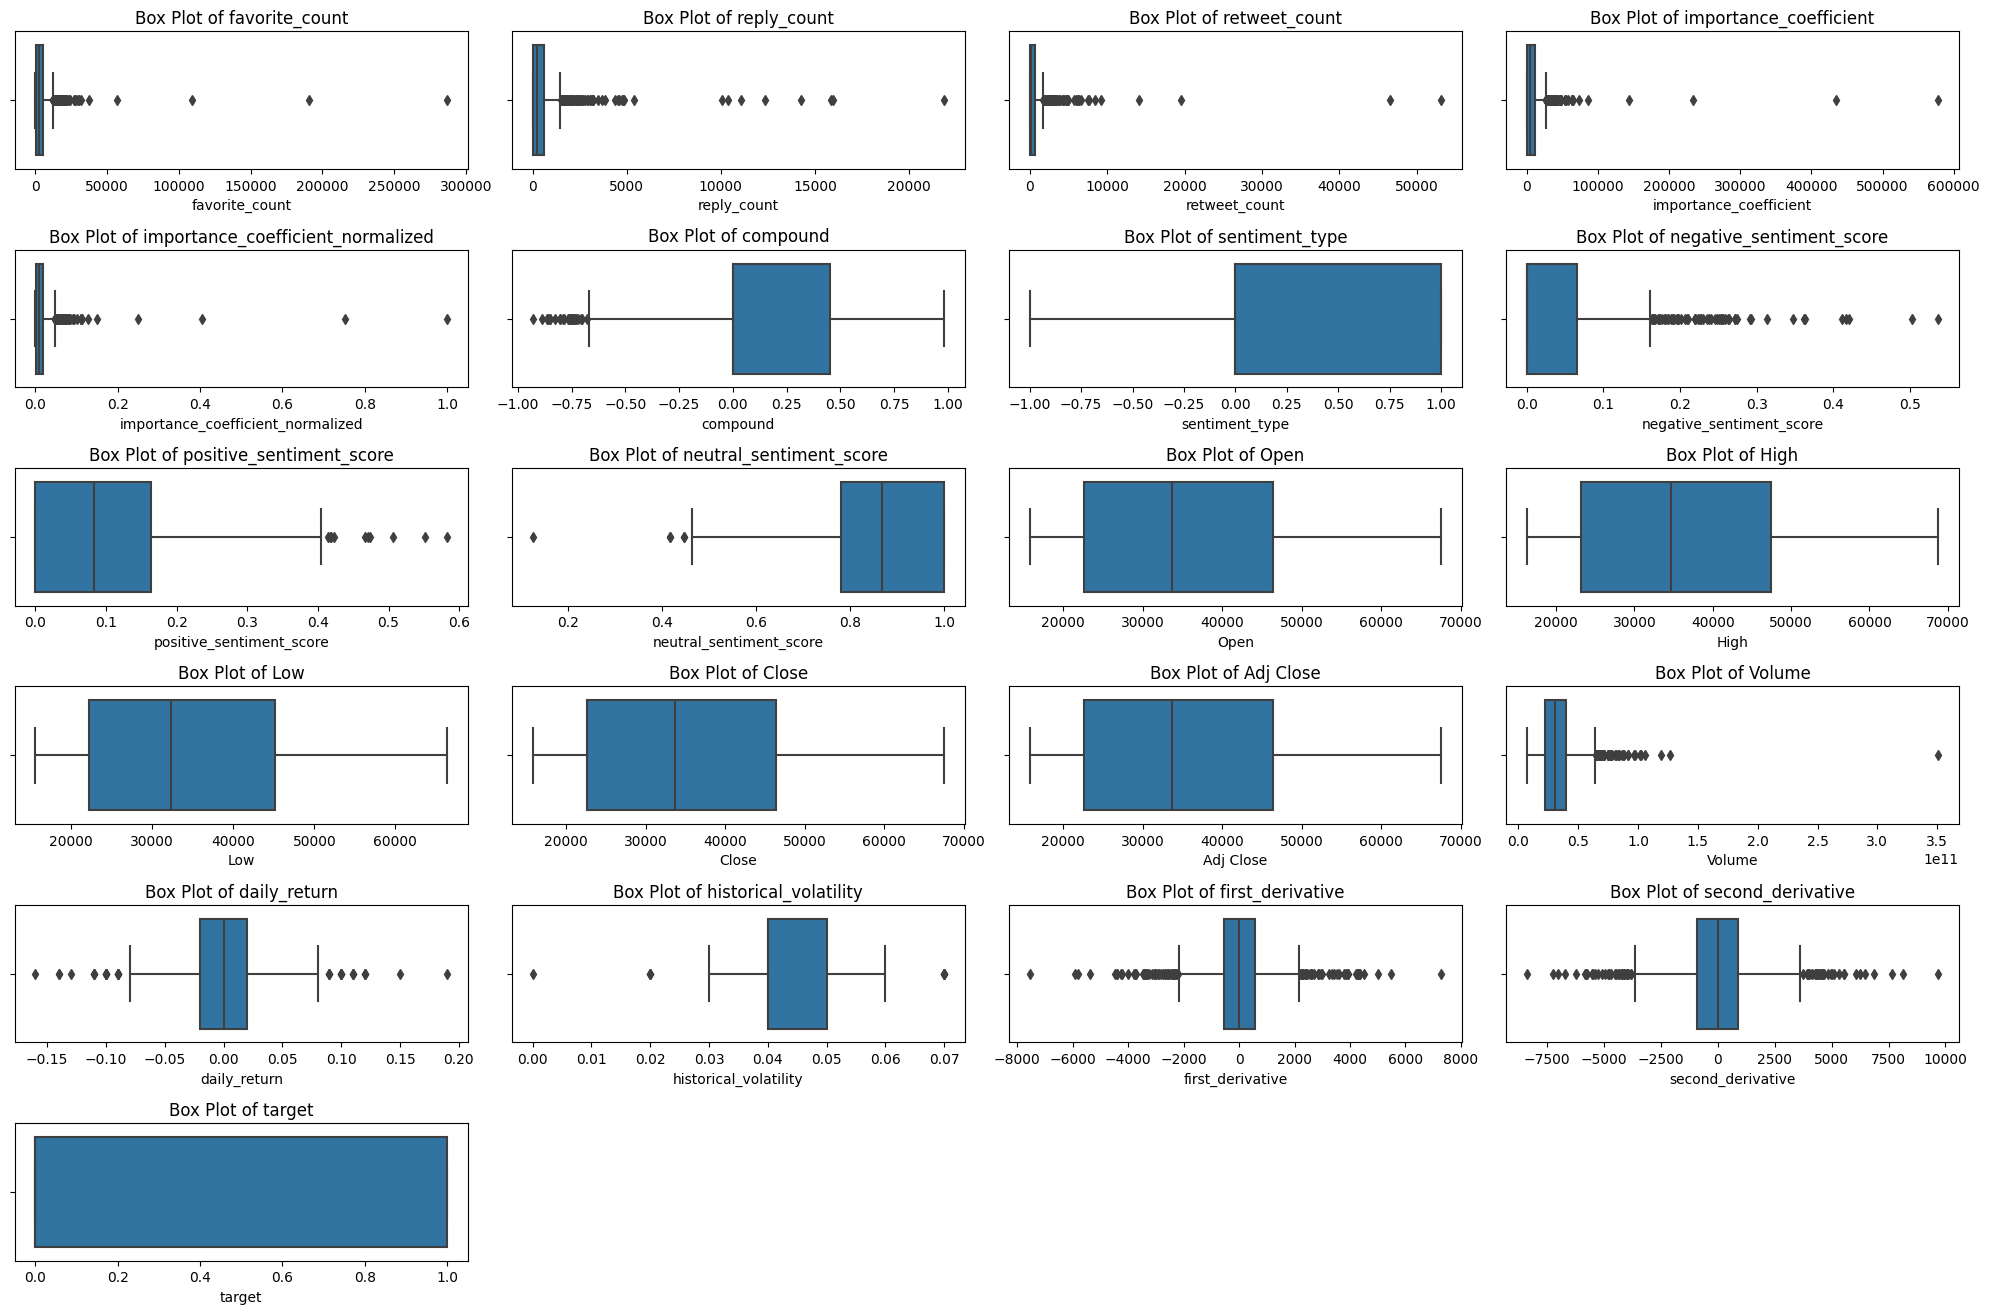

In [7]:
# Outlier Detection using box plots for the numerical columns
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_columns):
    plt.subplot(7, 4, i+1)
    sns.boxplot(x=preprocessed_data[col])
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()

plt.show()

* The box represents the interquartile range (IQR), which is the range between the 25th and 75th percentiles.

* The line within the box is the median.

* The "whiskers" extend to 1.5 times the IQR above and below the box. Points outside this range are often considered outliers.

* Outliers are represented as individual points beyond the whiskers.

## Time Series Analysis

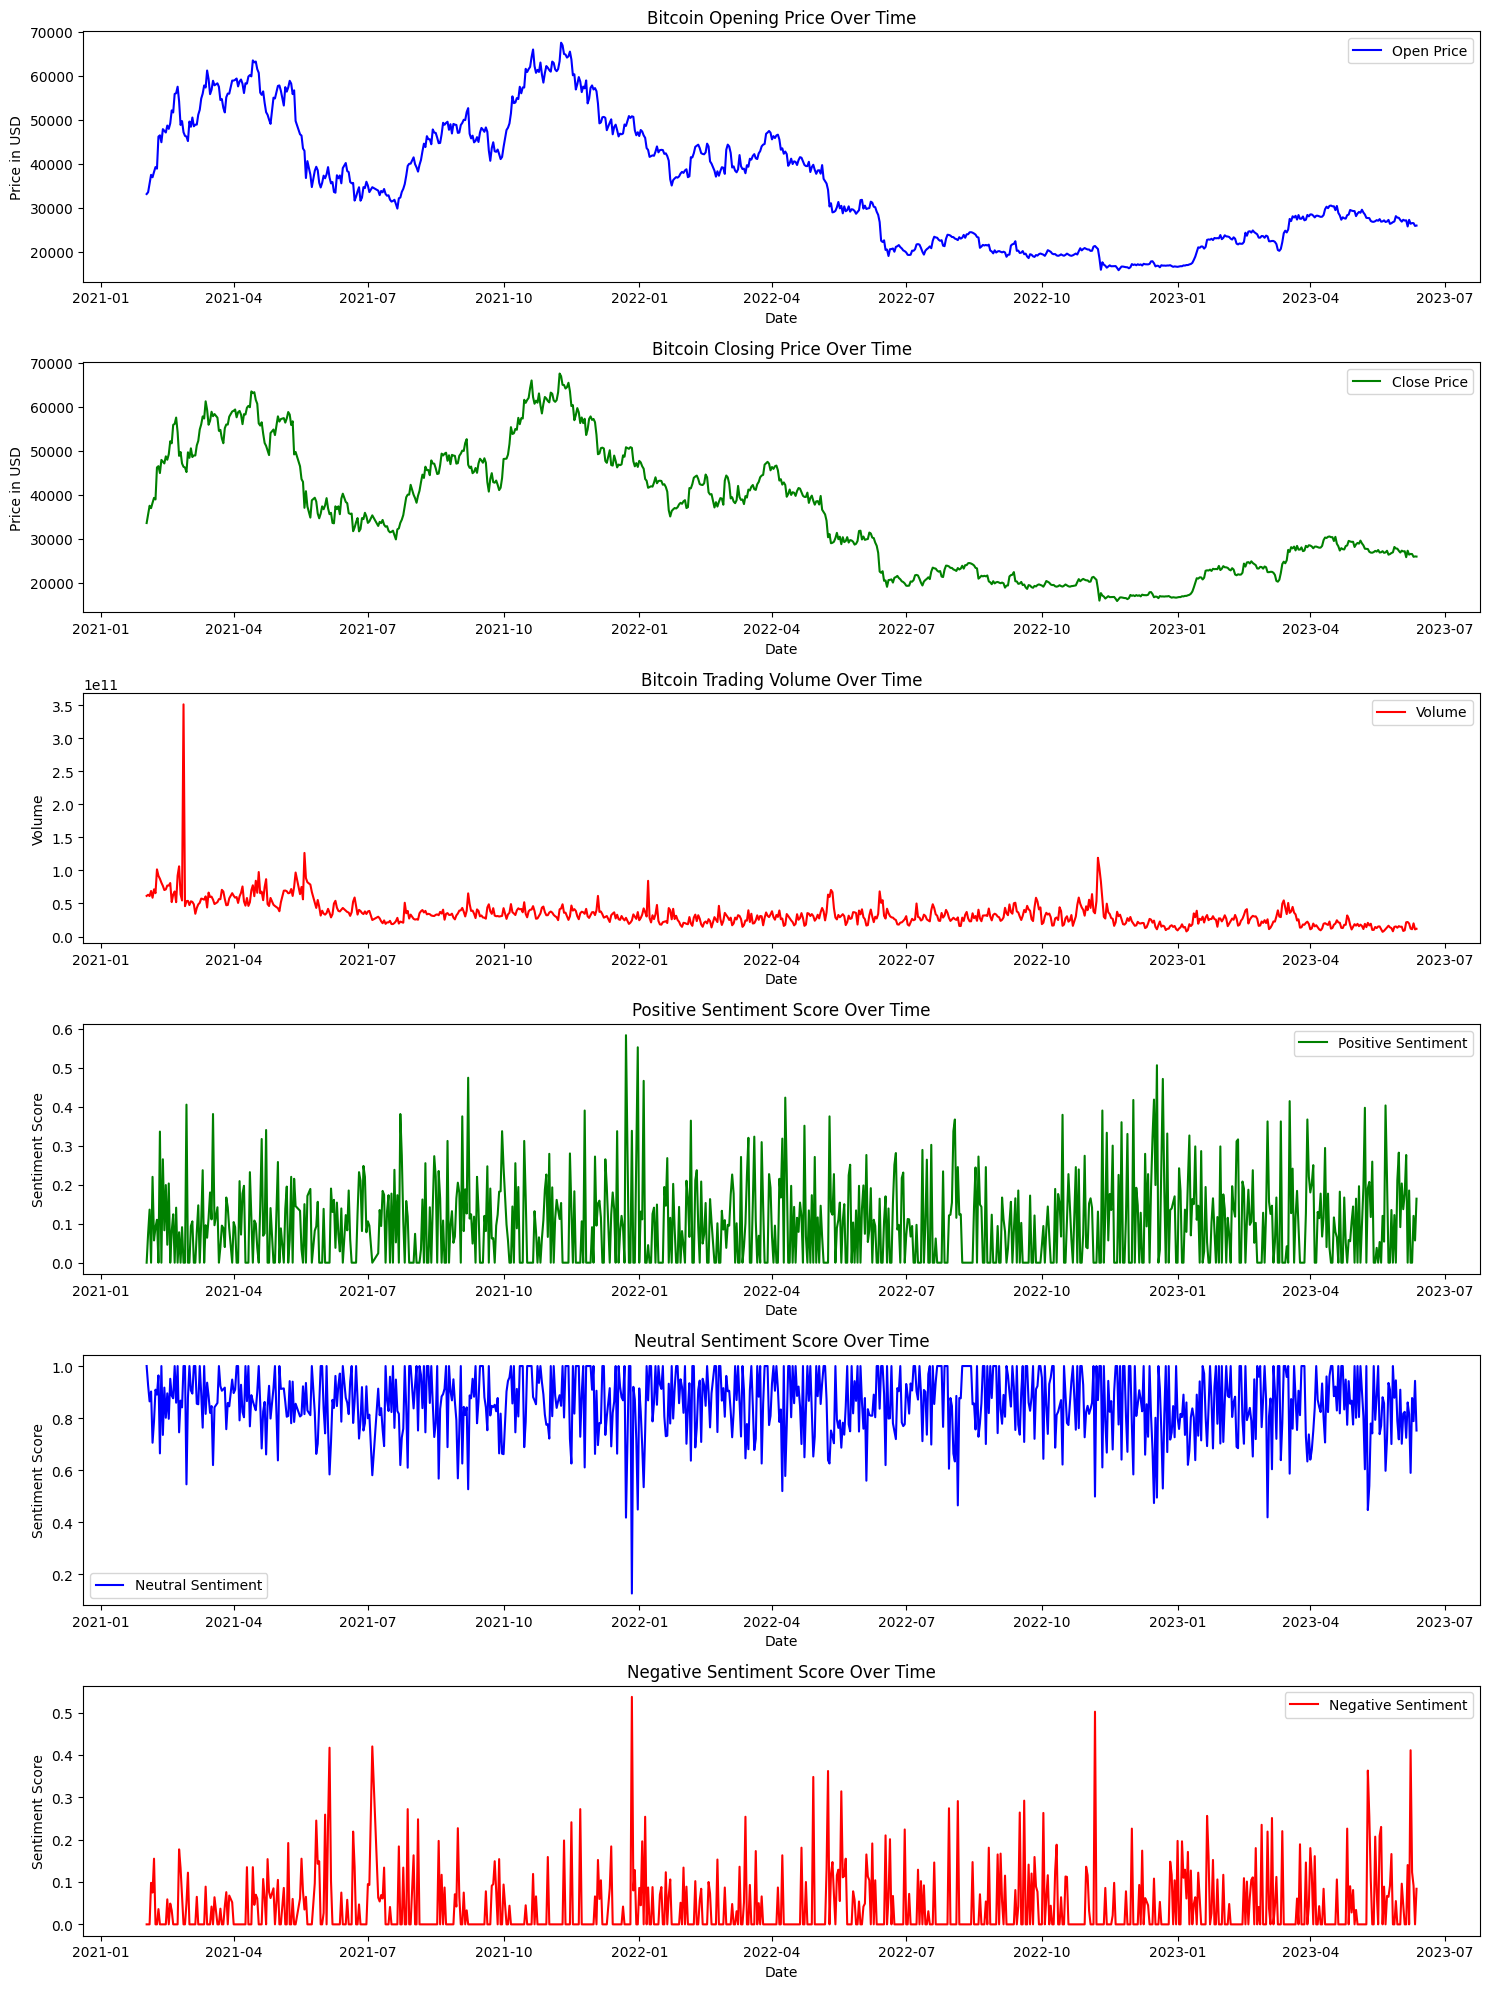

In [8]:
# Convert 'Date' to datetime format for time series analysis
preprocessed_data['Date'] = pd.to_datetime(preprocessed_data['Date'])

# Plotting time series data for key Bitcoin market metrics
plt.figure(figsize=(15, 20))

# Bitcoin Opening Price over Time
plt.subplot(6, 1, 1)
plt.plot(preprocessed_data['Date'], preprocessed_data['Open'], label='Open Price', color='blue')
plt.title('Bitcoin Opening Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()

# Bitcoin Closing Price over Time
plt.subplot(6, 1, 2)
plt.plot(preprocessed_data['Date'], preprocessed_data['Close'], label='Close Price', color='green')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()

# Bitcoin Volume over Time
plt.subplot(6, 1, 3)
plt.plot(preprocessed_data['Date'], preprocessed_data['Volume'], label='Volume', color='red')
plt.title('Bitcoin Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()

# Positive Sentiment Score over Time
plt.subplot(6, 1, 4)
plt.plot(preprocessed_data['Date'], preprocessed_data['positive_sentiment_score'], label='Positive Sentiment', color='green')
plt.title('Positive Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend()

# Neutral Sentiment Score over Time
plt.subplot(6, 1, 5)
plt.plot(preprocessed_data['Date'], preprocessed_data['neutral_sentiment_score'], label='Neutral Sentiment', color='blue')
plt.title('Neutral Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend()

# Negative Sentiment Score over Time
plt.subplot(6, 1, 6)
plt.plot(preprocessed_data['Date'], preprocessed_data['negative_sentiment_score'], label='Negative Sentiment', color='red')
plt.title('Negative Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend()

plt.tight_layout()
plt.show()

## Correlation Analysis

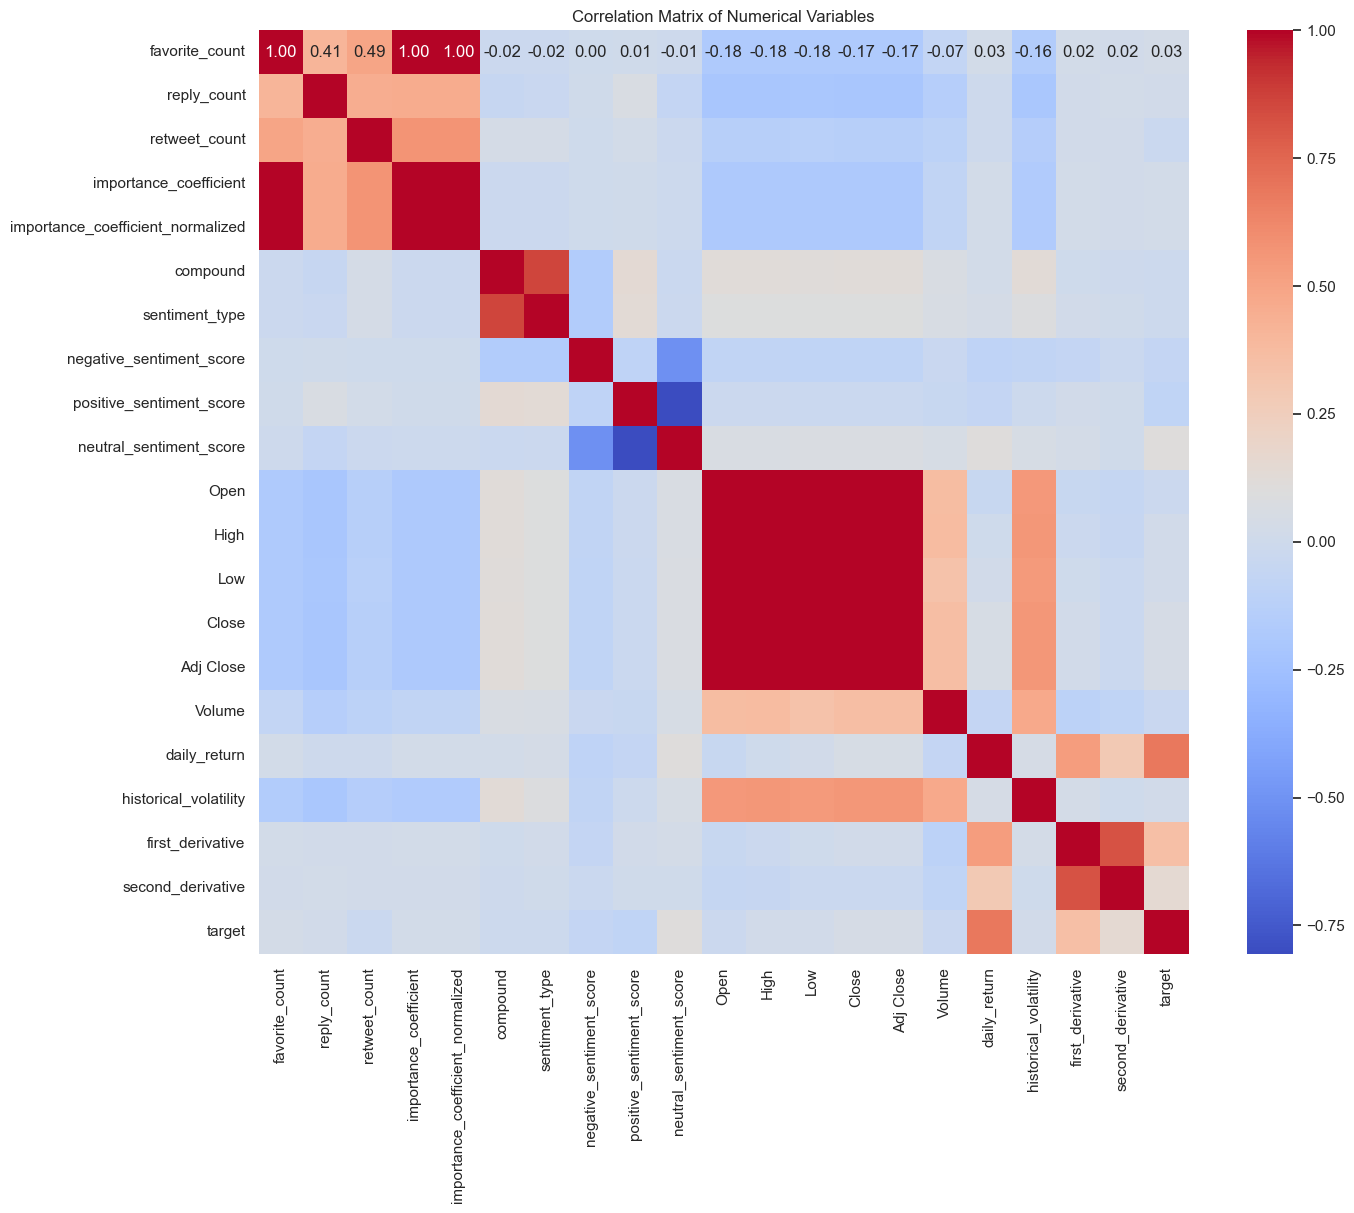

In [40]:
# Calculating the correlation matrix for the numerical columns
correlation_matrix = preprocessed_data[numerical_columns].corr()

# Plotting the heatmap for the correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

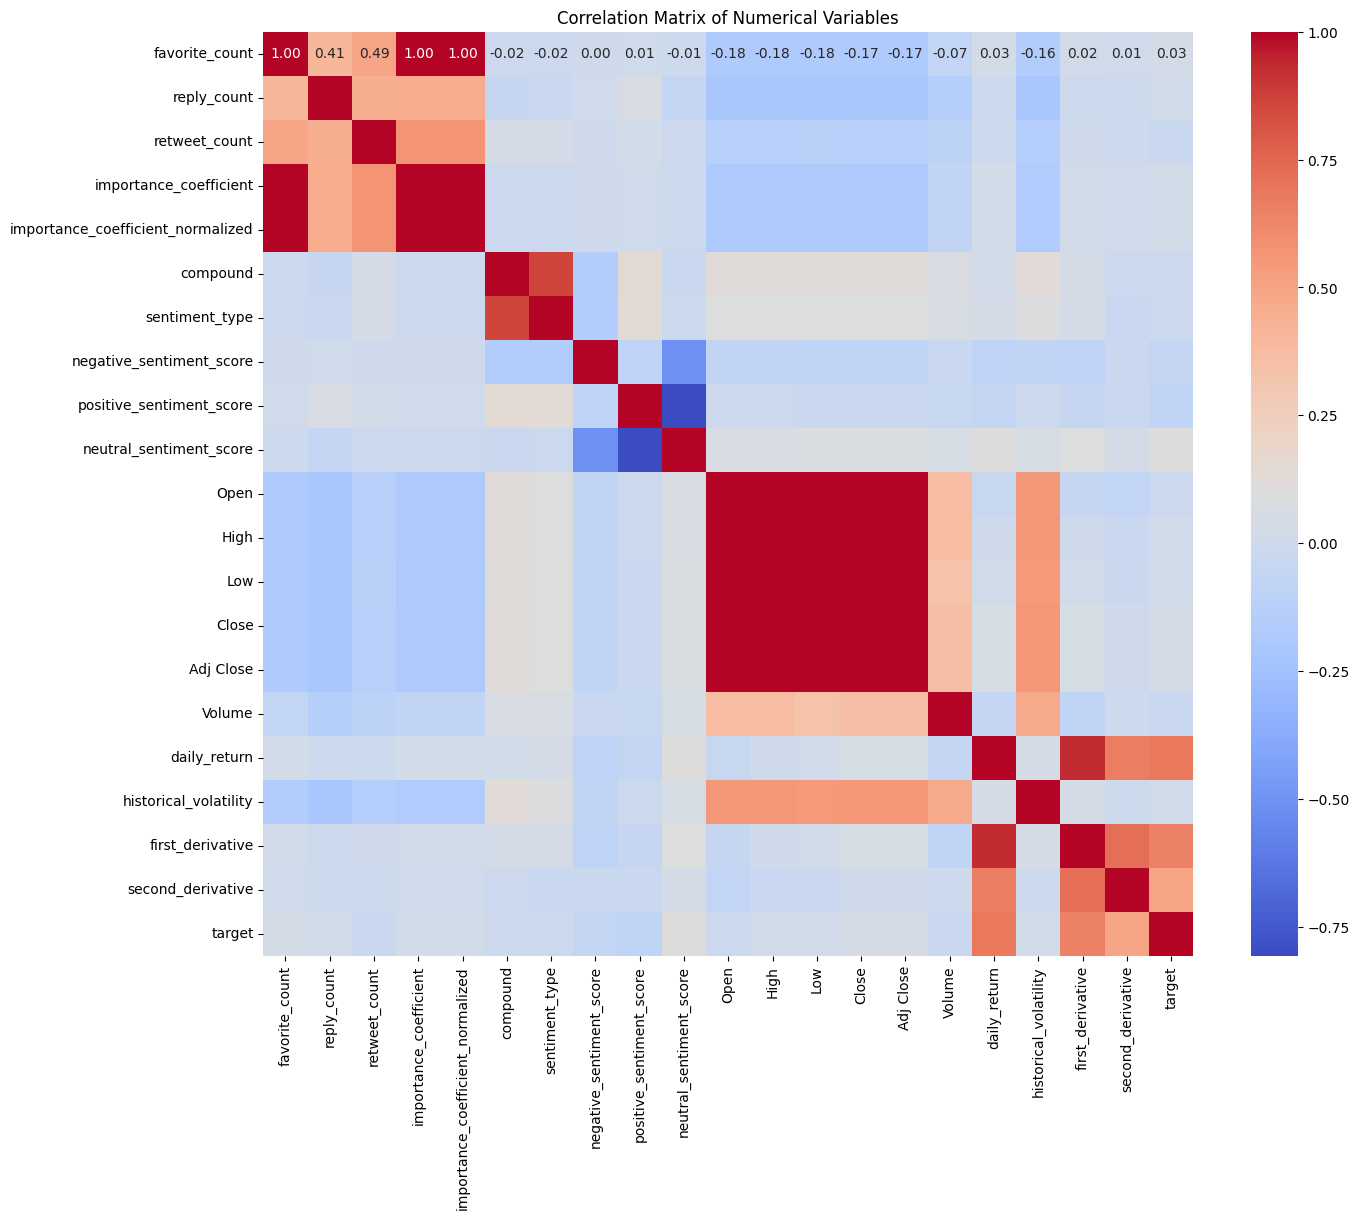

In [10]:
# Calculating the correlation matrix for the numerical columns
correlation_matrix_2 = preprocessed_data[numerical_columns].corr()

# Plotting the heatmap for the correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix_2, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

**Correlated features groups:**
* favorite_count, importance_coefficient, importance_coefficient_normalized, retweet_count, reply_count
* coumpound, sentiment_type
* Open, High, Low, Close, Adj Close, Volume, daily_return, historical_volatility
* daily_return, first_derivative, second_derivative, target

## Feature Relationships

c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is depr

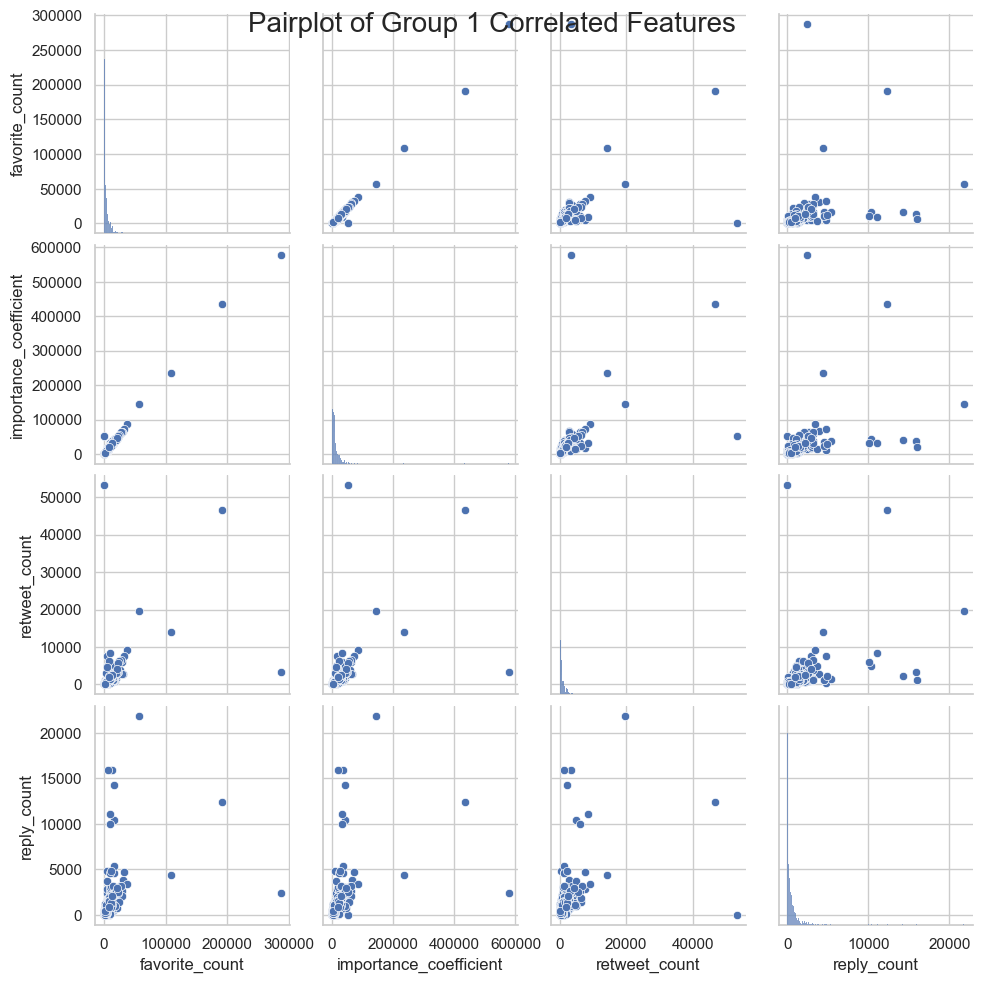

c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is depr

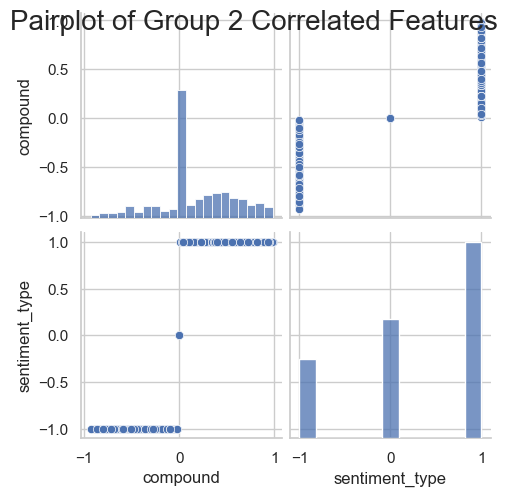

c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is depr

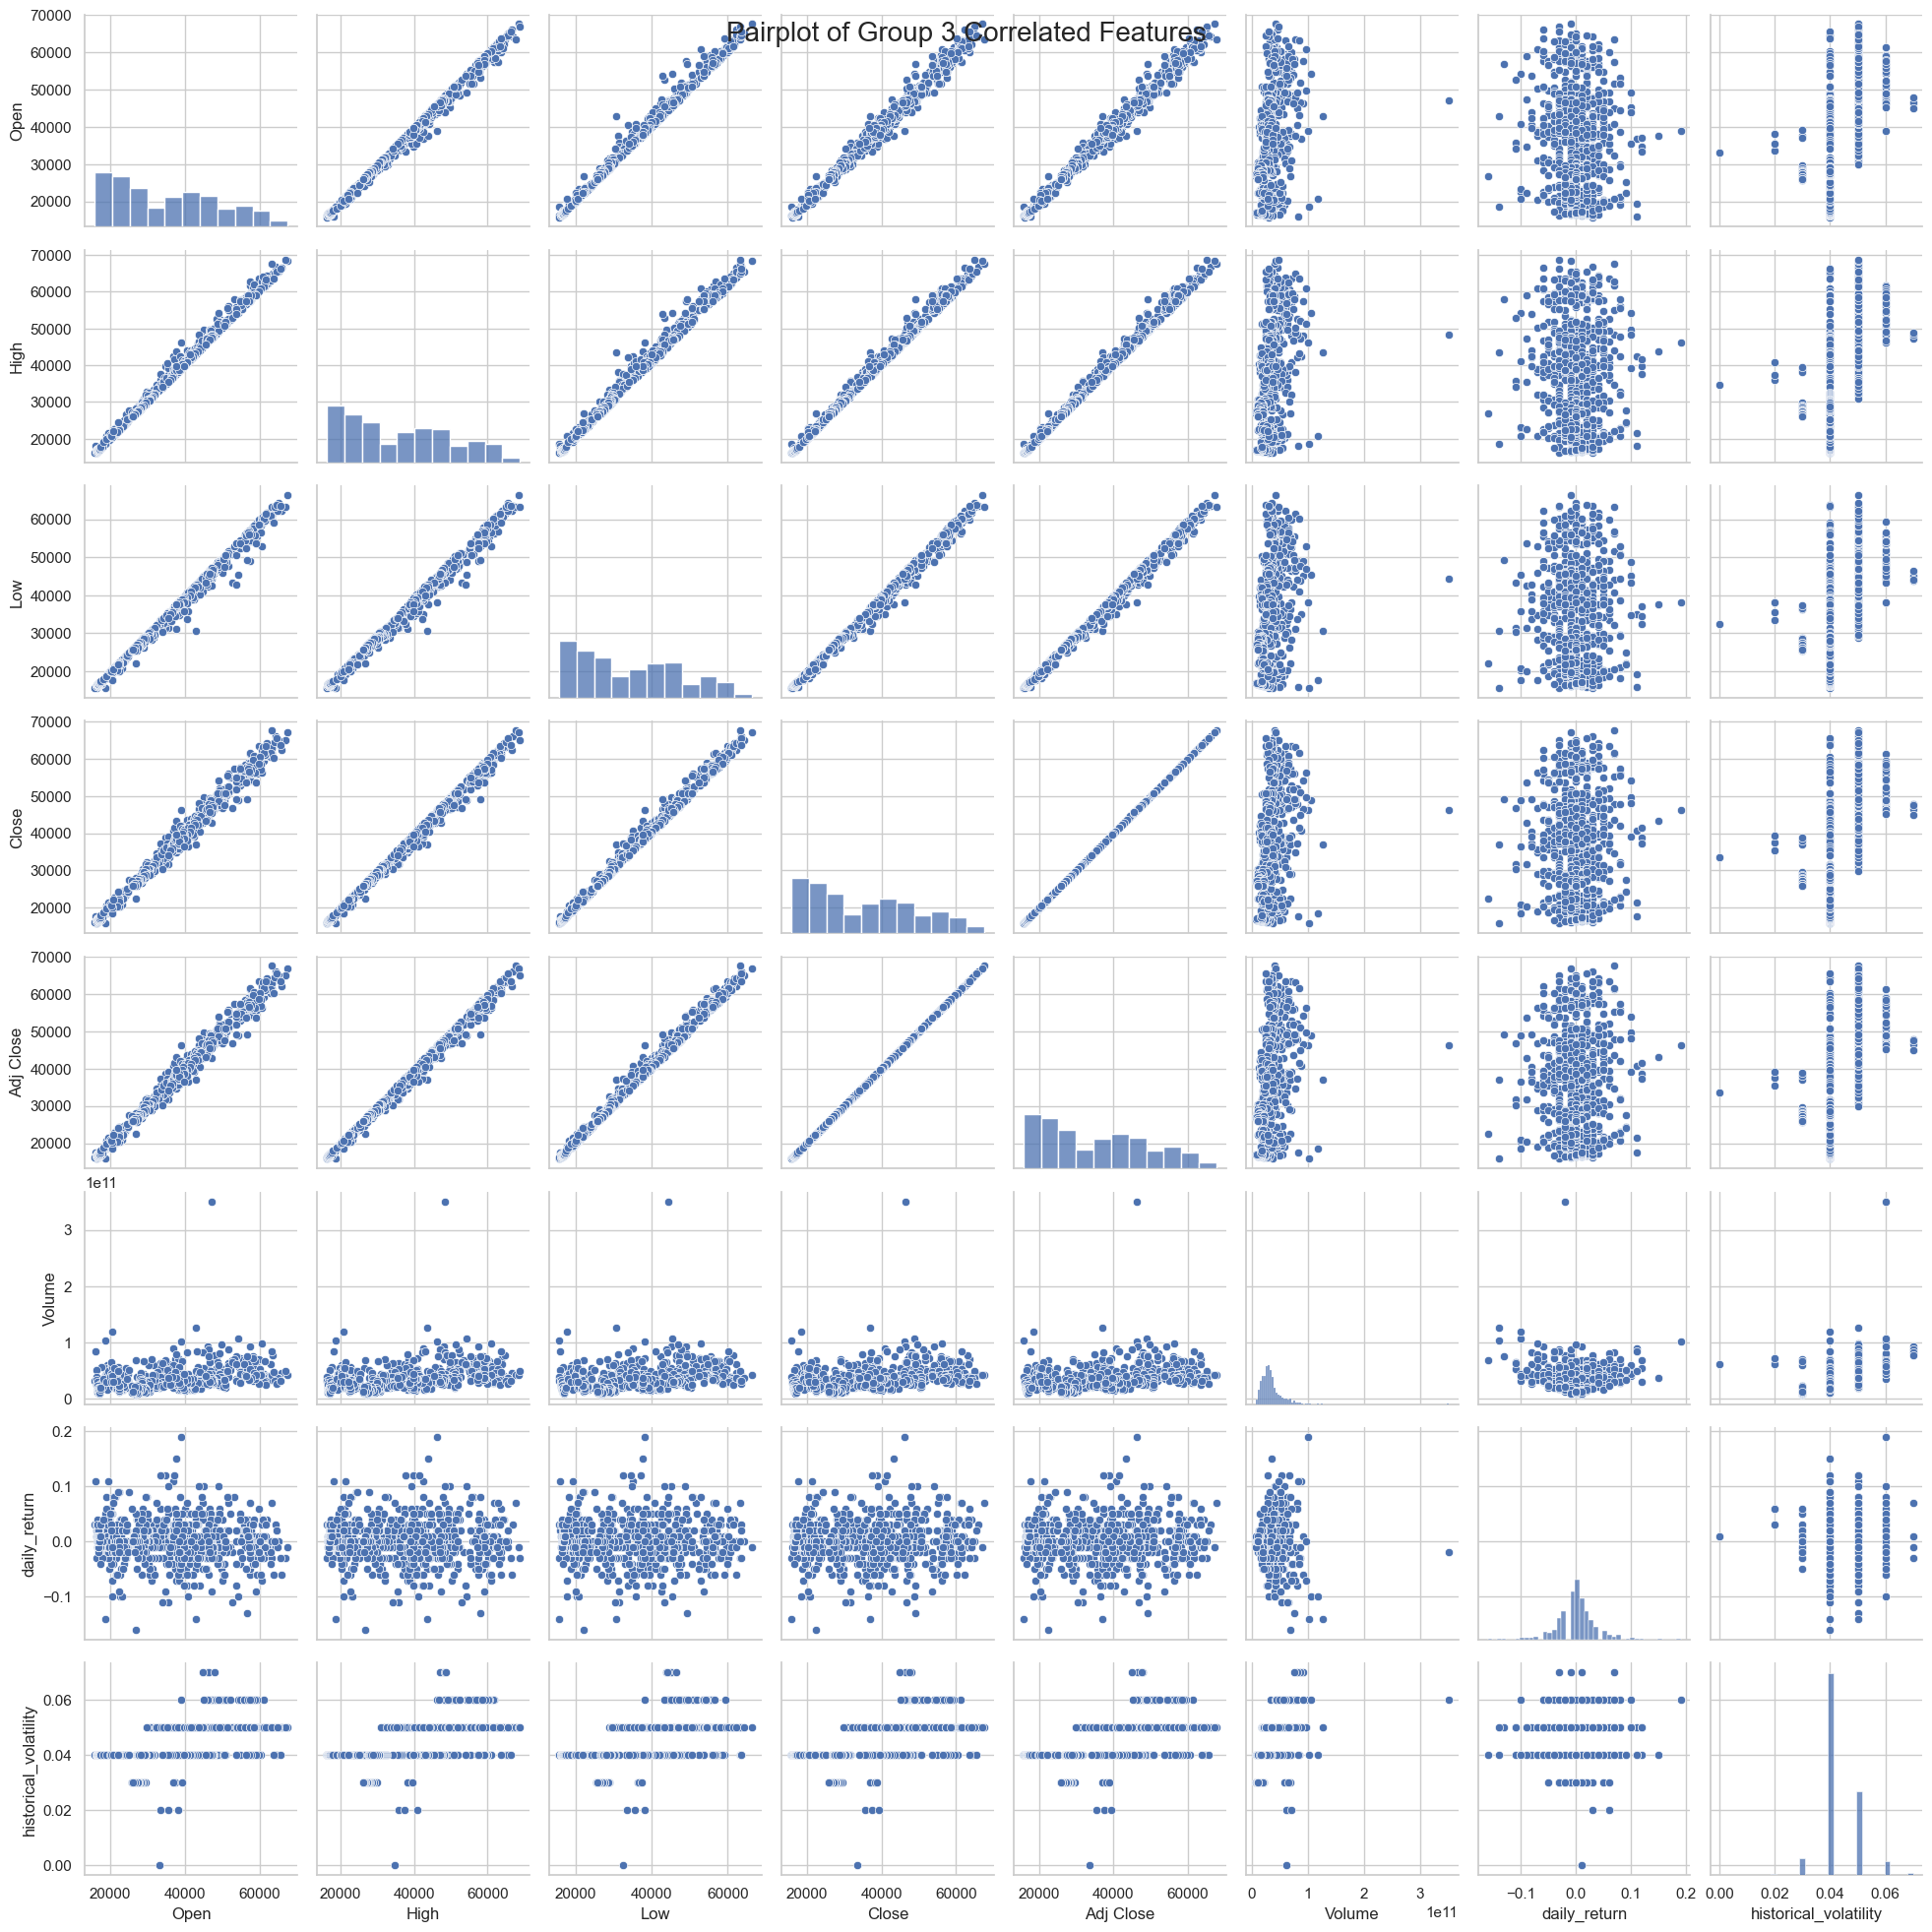

c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\natha\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is depr

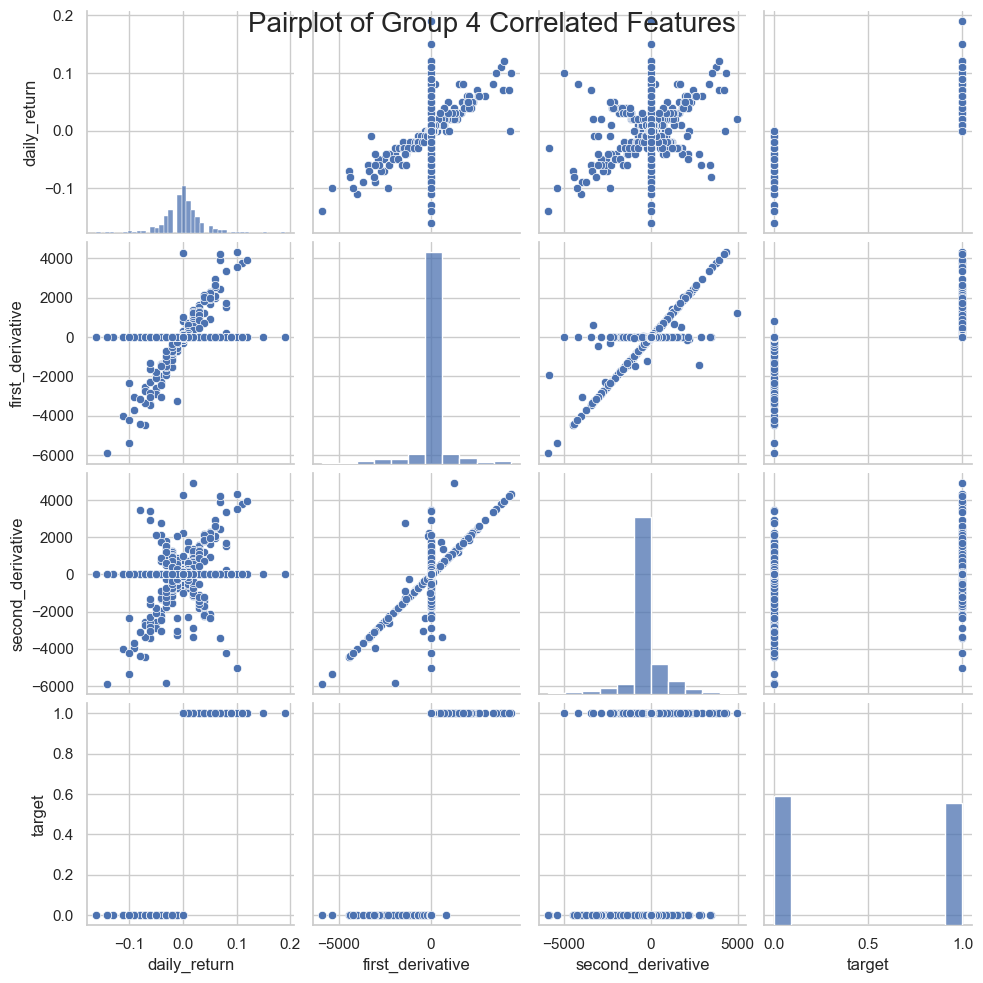

In [42]:
# Analyzing relationships between correlated features
features_g1 = ['favorite_count', 'importance_coefficient', 'retweet_count', 'reply_count']
features_g2 = ['compound', 'sentiment_type']
features_g3 = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'daily_return', 'historical_volatility']
features_g4 = ['daily_return', 'first_derivative', 'second_derivative', 'target']

# Pairplot for Group 1
sns.pairplot(preprocessed_data[features_g1])
plt.suptitle('Pairplot of Group 1 Correlated Features', size=20)
plt.show()

# Pairplot for Group 2
sns.pairplot(preprocessed_data[features_g2])
plt.suptitle('Pairplot of Group 2 Correlated Features', size=20)
plt.show()

# Pairplot for Group 3
sns.pairplot(preprocessed_data[features_g3])
plt.suptitle('Pairplot of Group 3 Correlated Features', size=20)
plt.show()

# Pairplot for Group 4
sns.pairplot(preprocessed_data[features_g4])
plt.suptitle('Pairplot of Group 4 Correlated Features', size=20)
plt.show()

## Text Data Analysis

See `EDA.ipynb` file for more details.